In [10]:
import tensorflow as tf
print(tf.__version__)


2.17.1


Check CUDA

In [ ]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("CUDA devices:", torch.cuda.device_count())
print("Current device:", torch.cuda.current_device())

Check pixel coord file

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import os

# Path to your folder containing images
image_folder = '../1_DatasetCharacteristics/seamounts_seg_cropped'

# Load the CSV file
csv_file = '../1_DatasetCharacteristics/merged_pixel_coordinates.csv'
df = pd.read_csv(csv_file)

# Loop through each row in the CSV file
for _, row in df.iterrows():
    # Get image file name and bounding box coordinates
    image_name = row['image_name']
    x_min, y_min, x_max, y_max = row['x_min'], row['y_min'], row['x_max'], row['y_max']

    # Load the image
    image_path = os.path.join(image_folder, image_name)
    image = cv2.imread(image_path)

    # Convert image from BGR (OpenCV format) to RGB (matplotlib format)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Draw the bounding box on the image
    cv2.rectangle(image_rgb, (x_min, y_min), (x_max, y_max), (255, 0, 0), 2)  # Red bounding box

    # Display the image with the bounding box
    plt.figure(figsize=(10, 10))
    plt.imshow(image_rgb)
    plt.axis('off')  # Turn off axis
    plt.show()


In [1]:
import os
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
import cv2
import numpy as np
import matplotlib.pyplot as plt
import albumentations as A
from albumentations.core.bbox_utils import BboxParams

# Paths to data
image_dir = "/content/train"
csv_path = "/content/merged_pixel_coordinates.csv"

# Constants
IMAGE_SIZE = (256, 256)  # Resize images to 256x256
BATCH_SIZE = 32
EPOCHS = 50

# Load bounding box data
bbox_data = pd.read_csv(csv_path)

# Function to load images
def load_image(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_COLOR)  # Load in color (BGR format)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert to RGB format
    image = image / 255.0  # Normalize pixel values to [0, 1]
    return image

# Function to preprocess bounding boxes
def preprocess_bboxes(row, original_size, resized_size):
    x_min, y_min, x_max, y_max = row[['x_min', 'y_min', 'x_max', 'y_max']]
    orig_height, orig_width = original_size
    resized_height, resized_width = resized_size

    # Scale the bounding box coordinates according to the resizing ratio
    x_min = x_min * (resized_width / orig_width)
    y_min = y_min * (resized_height / orig_height)
    x_max = x_max * (resized_width / orig_width)
    y_max = y_max * (resized_height / orig_height)

    # Normalize coordinates to [0, 1]
    x_min /= resized_width
    y_min /= resized_height
    x_max /= resized_width
    y_max /= resized_height

    return [x_min, y_min, x_max, y_max]

# Augmentation pipeline
augmentation_pipeline = A.Compose(
    [
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.2),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=15, p=0.5),
    ],
    bbox_params=BboxParams(format='albumentations', label_fields=['class_labels'])
)

# Prepare dataset
images = []
bboxes = []
augmented_images = []
augmented_bboxes = []

for _, row in bbox_data.iterrows():
    img_path = os.path.join(image_dir, row['image_name'])
    if os.path.exists(img_path):
        # Load image and preprocess bounding box
        original_image = load_image(img_path)
        original_size = (original_image.shape[0], original_image.shape[1])
        bbox = preprocess_bboxes(row, original_size, IMAGE_SIZE)

        # Add original data
        resized_image = cv2.resize(original_image, IMAGE_SIZE)
        images.append(resized_image)
        bboxes.append(bbox)

        # Prepare data for augmentation
        bbox_aug = [bbox]
        class_labels = ['seamount']

        try:
            # Apply augmentation
            augmented = augmentation_pipeline(
                image=original_image,
                bboxes=bbox_aug,
                class_labels=class_labels
            )

            # Validate augmentation outputs
            if len(augmented['bboxes']) == 1:  # Ensure a single bounding box exists
                augmented_images.append(cv2.resize(augmented['image'], IMAGE_SIZE))
                augmented_bboxes.append(augmented['bboxes'][0])  # Add augmented bbox
            else:
                print(f"Skipping augmentation due to invalid bbox for image: {img_path}")

        except Exception as e:
            print(f"Augmentation failed for image: {img_path}, Error: {e}")

# Convert to NumPy arrays
try:
    images = np.array(images)
    bboxes = np.array(bboxes)
    augmented_images = np.array(augmented_images)
    augmented_bboxes = np.array(augmented_bboxes)
except ValueError as e:
    print(f"Error converting to NumPy arrays: {e}")
    print(f"Images shape: {[img.shape for img in augmented_images]}")
    print(f"BBoxes shape: {augmented_bboxes}")


# Combine original and augmented data
all_images = np.concatenate([images, augmented_images], axis=0)
all_bboxes = np.concatenate([bboxes, augmented_bboxes], axis=0)

# Split data
X_train, X_val, y_train, y_val = train_test_split(all_images, all_bboxes, test_size=0.2, random_state=42)

# Define Huber loss
def huber_loss(y_true, y_pred, delta=1.0):
    error = y_true - y_pred
    is_small_error = tf.abs(error) <= delta
    small_error_loss = 0.5 * tf.square(error)
    large_error_loss = delta * (tf.abs(error) - 0.5 * delta)
    return tf.where(is_small_error, small_error_loss, large_error_loss)

# Define the model architecture
def create_model():
    inputs = layers.Input(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3))  # 3 channels for RGB
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)  # Add dropout to prevent overfitting
    outputs = layers.Dense(4, activation='linear')(x)  # Use 'linear' activation for raw predictions
    model = models.Model(inputs, outputs)
    return model

# Compile model with Huber loss
model = create_model()
model.compile(optimizer='adam', loss=huber_loss, metrics=['mae'])

# Train the model and get history
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

# Save the trained model
model_save_path = "objdet_standalone_1_0_model.h5"  # Path where the model will be saved
model.save(model_save_path)
print(f"Model saved to {model_save_path}")

# Evaluate model performance
val_loss, val_mae = model.evaluate(X_val, y_val)
print(f"Validation Loss: {val_loss}, Validation MAE: {val_mae}")


/usr/local/lib/python3.10/dist-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 1.4.24 (you have 1.4.20). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 23s 615ms/step - loss: 1.3447 - mae: 1.6458 - val_loss: 0.0095 - val_mae: 0.1173
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 21s 75ms/step - loss: 0.0156 - mae: 0.1437 - val_loss: 0.0015 - val_mae: 0.0418
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - loss: 0.0115 - mae: 0.1208 - val_loss: 0.0017 - val_mae: 0.0464
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - loss: 0.0098 - mae: 0.1092 - val_loss: 0.0030 - val_mae: 0.0654
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - loss: 0.0098 - mae: 0.1111 - val_loss: 0.0013 - val_mae: 0.0382
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - loss: 0.0085 - mae: 0.1035 - val_loss: 9.8337e-04 - val_mae: 0.0326
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - loss: 0.0072 - mae: 0.0949 - val_loss: 0.0036 - val_mae: 0.0721
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - loss: 0.0084 - mae: 0.1020 - val_loss: 9.7964e-04 - val_mae: 0.0328
Epoch 9/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - 

Model saved to objdet_standalone_1_0_model.h5
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 7.7483e-04 - mae: 0.0307
Validation Loss: 0.0007697879918850958, Validation MAE: 0.03047078289091587


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 827ms/step


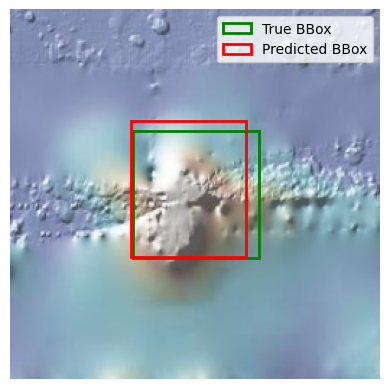

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


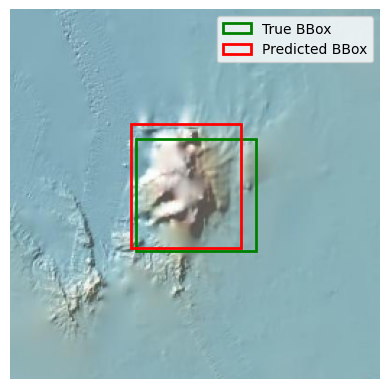

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


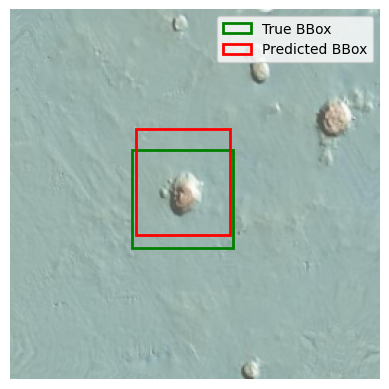

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


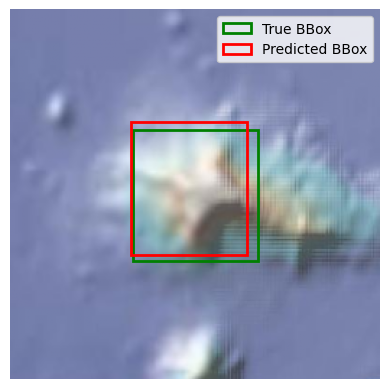

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


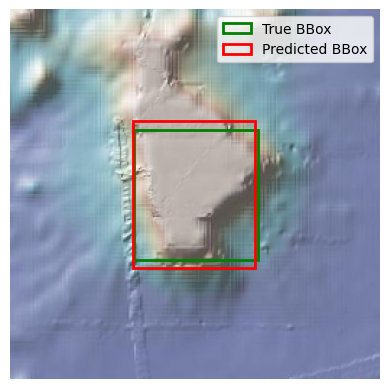

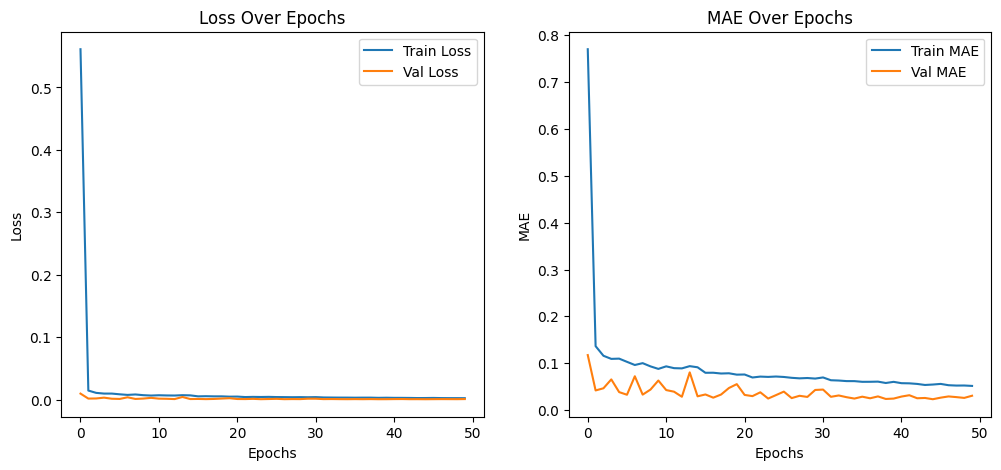

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


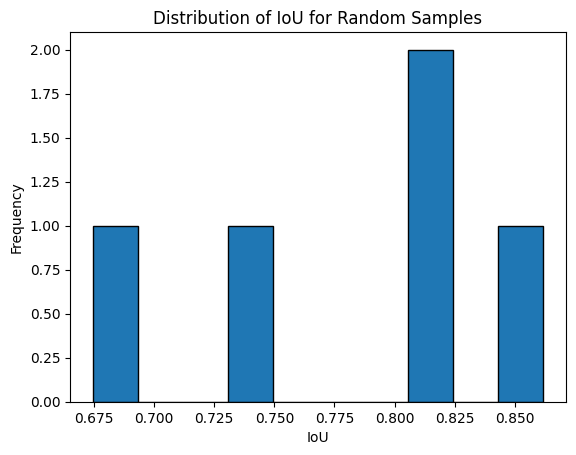

Average IoU: 0.7789


In [3]:
# -------------------------------------------------------------
# Evaluation Visualizations

# Function to plot image with bounding boxes
def plot_image_with_bboxes(image, true_bbox, pred_bbox=None):
    plt.imshow(image)
    h, w, _ = image.shape

    # Plot ground truth bounding box
    x_min, y_min, x_max, y_max = true_bbox
    plt.gca().add_patch(plt.Rectangle(
        (x_min * w, y_min * h),  # Convert normalized coordinates to image scale
        (x_max - x_min) * w,
        (y_max - y_min) * h,
        linewidth=2, edgecolor='g', facecolor='none', label='True BBox'))

    # Plot predicted bounding box if provided
    if pred_bbox is not None:
        x_min, y_min, x_max, y_max = pred_bbox
        plt.gca().add_patch(plt.Rectangle(
            (x_min * w, y_min * h),  # Convert normalized coordinates to image scale
            (x_max - x_min) * w,
            (y_max - y_min) * h,
            linewidth=2, edgecolor='r', facecolor='none', label='Predicted BBox'))

    plt.legend()
    plt.axis('off')
    plt.show()

# Random sample of predictions
sample_indices = np.random.choice(len(X_val), 5)  # 5 random samples

for idx in sample_indices:
    image = X_val[idx]
    true_bbox = y_val[idx]

    # Predict bounding box
    pred_bbox = model.predict(np.expand_dims(image, axis=0))[0]

    # Plot the image with true and predicted bounding boxes
    plot_image_with_bboxes(image, true_bbox, pred_bbox)

# -------------------------------------------------------------
# Loss and MAE Curves Over Epochs
plt.figure(figsize=(12, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# MAE plot
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.title('MAE Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()

plt.show()

# -------------------------------------------------------------
# IoU Metric
def compute_iou(true_bbox, pred_bbox):
    x_min_true, y_min_true, x_max_true, y_max_true = true_bbox
    x_min_pred, y_min_pred, x_max_pred, y_max_pred = pred_bbox

    # Calculate the coordinates of the intersection
    x_min_inter = max(x_min_true, x_min_pred)
    y_min_inter = max(y_min_true, y_min_pred)
    x_max_inter = min(x_max_true, x_max_pred)
    y_max_inter = min(y_max_true, y_max_pred)

    # Calculate area of intersection
    inter_area = max(0, x_max_inter - x_min_inter) * max(0, y_max_inter - y_min_inter)

    # Calculate area of both bounding boxes
    true_area = (x_max_true - x_min_true) * (y_max_true - y_min_true)
    pred_area = (x_max_pred - x_min_pred) * (y_max_pred - y_min_pred)

    # Calculate IoU
    iou = inter_area / (true_area + pred_area - inter_area)
    return iou

# Calculate IoU for a few samples
ious = []
for idx in sample_indices:
    true_bbox = y_val[idx]
    pred_bbox = model.predict(np.expand_dims(X_val[idx], axis=0))[0]
    iou = compute_iou(true_bbox, pred_bbox)
    ious.append(iou)

# Plot the IoU distribution
plt.hist(ious, bins=10, edgecolor='black')
plt.title('Distribution of IoU for Random Samples')
plt.xlabel('IoU')
plt.ylabel('Frequency')
plt.show()

# Print average IoU
average_iou = np.mean(ious)
print(f"Average IoU: {average_iou:.4f}")

In [13]:
# In the original script where the model was trained
model.export('model_saved_model')  # Saves in the TensorFlow SavedModel format


Saved artifact at 'model_saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  135846436001344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135846434658208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135846434655920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135846425007856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135846425012080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135846425008912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135846425016128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135846425009616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135846425013136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135846425071808: TensorSpec(shape=(), dtype=tf.resource, name=None)


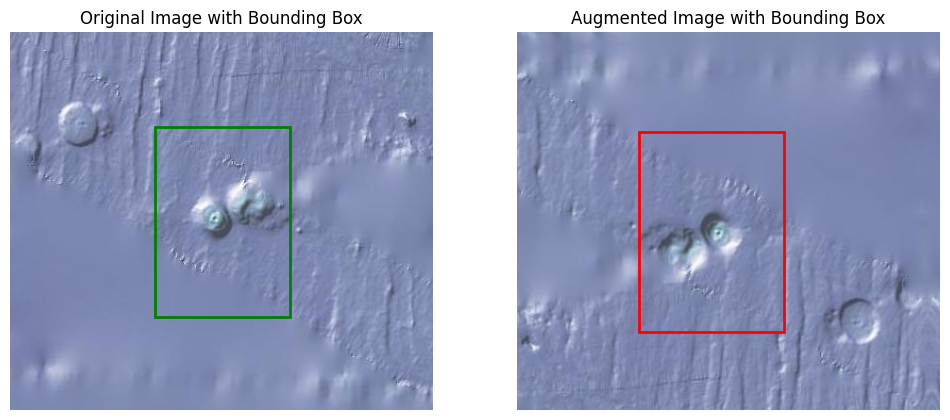

In [9]:
import matplotlib.pyplot as plt
import albumentations as A
from albumentations.core.bbox_utils import BboxParams

# Example function to visualize the augmentation
def visualize_augmentation(original_image, original_bbox, augmentation_pipeline):
    # Augment the image and bounding box
    bbox_aug = [original_bbox]
    class_labels = ['seamount']

    augmented = augmentation_pipeline(
        image=original_image,
        bboxes=bbox_aug,
        class_labels=class_labels
    )

    # Get the augmented image and bounding box
    augmented_image = augmented['image']
    augmented_bbox = augmented['bboxes'][0]

    # Plot original image and augmented image side by side
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # Plot original image with bbox
    axes[0].imshow(original_image)
    axes[0].set_title("Original Image with Bounding Box")
    h, w, _ = original_image.shape
    x_min, y_min, x_max, y_max = original_bbox
    axes[0].add_patch(plt.Rectangle(
        (x_min * w, y_min * h),  # Convert normalized coordinates to image scale
        (x_max - x_min) * w,
        (y_max - y_min) * h,
        linewidth=2, edgecolor='g', facecolor='none', label='True BBox'))
    axes[0].axis('off')

    # Plot augmented image with bbox
    axes[1].imshow(augmented_image)
    axes[1].set_title("Augmented Image with Bounding Box")
    h, w, _ = augmented_image.shape
    x_min, y_min, x_max, y_max = augmented_bbox
    axes[1].add_patch(plt.Rectangle(
        (x_min * w, y_min * h),  # Convert normalized coordinates to image scale
        (x_max - x_min) * w,
        (y_max - y_min) * h,
        linewidth=2, edgecolor='r', facecolor='none', label='Augmented BBox'))
    axes[1].axis('off')

    plt.show()

# Example: Visualizing the augmentation
# Assuming `bbox_data` contains the bounding box information
for _, row in bbox_data.iterrows():
    img_path = os.path.join(image_dir, row['image_name'])
    if os.path.exists(img_path):
        # Load image and preprocess bounding box
        original_image = load_image(img_path)
        original_size = (original_image.shape[0], original_image.shape[1])
        original_bbox = preprocess_bboxes(row, original_size, IMAGE_SIZE)

        # Visualize augmentation
        visualize_augmentation(original_image, original_bbox, augmentation_pipeline)
        break  # Visualize just one example for testing purposes


In [2]:
print(model)  # This will throw an error if model is not defined

<Functional name=functional, built=True>
